In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns",None)

In [2]:
import os 
os.listdir()

['.ipynb_checkpoints',
 'AdventureWorksDW.XLSX',
 'Dashboard.pbix',
 'dashboard.png',
 'Document from Shivam Sachan.pdf',
 'Project.ipynb',
 'Superstore.csv',
 'Superstore_Cleaned.csv',
 'Untitled.ipynb']

In [3]:
sales=pd.read_excel("AdventureWorksDW.XLSX",sheet_name="FactInternetSales")
product=pd.read_excel("AdventureWorksDW.XLSX",sheet_name="DimProduct")
customer=pd.read_excel("AdventureWorksDW.XLSX",sheet_name="DimCustomer")
territory=pd.read_excel("AdventureWorksDW.XLSX",sheet_name="DimSalesTerritory")
date=pd.read_excel("AdventureWorksDW.XLSX",sheet_name="DimDate")


In [4]:
geography = pd.read_excel("AdventureWorksDW.XLSX",
                          sheet_name="DimGeography")


In [5]:
print("sales :", sales.shape)
print("product :", product.shape)
print("customer :", customer.shape)
print("geography :", geography.shape)
print("territory :", territory.shape)
print("date :", date.shape)

sales : (60398, 26)
product : (606, 36)
customer : (18484, 29)
geography : (655, 11)
territory : (11, 6)
date : (2191, 19)


In [6]:
sales.isnull().sum()

ProductKey                   0
OrderDateKey                 0
DueDateKey                   0
ShipDateKey                  0
CustomerKey                  0
PromotionKey                 0
CurrencyKey                  0
SalesTerritoryKey            0
SalesOrderNumber             0
SalesOrderLineNumber         0
RevisionNumber               0
OrderQuantity                0
UnitPrice                    0
ExtendedAmount               0
UnitPriceDiscountPct         0
DiscountAmount               0
ProductStandardCost          0
TotalProductCost             0
SalesAmount                  0
TaxAmt                       0
Freight                      0
CarrierTrackingNumber    60398
CustomerPONumber         60398
OrderDate                    0
DueDate                      0
ShipDate                     0
dtype: int64

In [7]:
sales.drop(columns=["CarrierTrackingNumber","CustomerPONumber"],inplace=True)

In [8]:
sales.isnull().sum()

ProductKey              0
OrderDateKey            0
DueDateKey              0
ShipDateKey             0
CustomerKey             0
PromotionKey            0
CurrencyKey             0
SalesTerritoryKey       0
SalesOrderNumber        0
SalesOrderLineNumber    0
RevisionNumber          0
OrderQuantity           0
UnitPrice               0
ExtendedAmount          0
UnitPriceDiscountPct    0
DiscountAmount          0
ProductStandardCost     0
TotalProductCost        0
SalesAmount             0
TaxAmt                  0
Freight                 0
OrderDate               0
DueDate                 0
ShipDate                0
dtype: int64

In [9]:
product.isnull().sum()

ProductKey                 0
ProductAlternateKey        0
ProductSubcategoryKey    209
WeightUnitMeasureCode    324
SizeUnitMeasureCode      353
EnglishProductName         0
SpanishProductName       287
FrenchProductName        287
StandardCost             211
FinishedGoodsFlag          0
Color                    254
SafetyStockLevel           0
ReorderPoint               0
ListPrice                211
Size                     307
SizeRange                307
Weight                   324
DaysToManufacture          0
ProductLine              226
DealerPrice              211
Class                    276
Style                    305
ModelName                209
LargePhoto               606
EnglishDescription       210
FrenchDescription        210
ChineseDescription       210
ArabicDescription        210
HebrewDescription        210
ThaiDescription          210
GermanDescription        210
JapaneseDescription      210
TurkishDescription       210
StartDate                  0
EndDate       

In [10]:
columns_to_keep=["ProductKey",
"EnglishProductName",
"Color",
"ListPrice",
"EnglishDescription"]
product=product[columns_to_keep].copy()

In [11]:
product["Color"] = product["Color"].fillna("No Color")
product["EnglishDescription"] = product["EnglishDescription"].fillna("Not Available")

In [12]:
product.head()

,ProductKey,EnglishProductName,Color,ListPrice,EnglishDescription
0,1,Adjustable Race,No Color,NaN,Not Available
1,2,Bearing Ball,No Color,NaN,Not Available
2,3,BB Ball Bearing,No Color,NaN,Not Available
3,4,Headset Ball Bearings,No Color,NaN,Not Available
4,5,Blade,No Color,NaN,Not Available


In [13]:
customer.isnull().sum()

CustomerKey                 0
GeographyKey                0
CustomerAlternateKey        0
Title                   18383
FirstName                   0
MiddleName               7830
LastName                    0
NameStyle                   0
BirthDate                   0
MaritalStatus               0
Suffix                  18481
Gender                      0
EmailAddress                0
YearlyIncome                0
TotalChildren               0
NumberChildrenAtHome        0
EnglishEducation            0
SpanishEducation            0
FrenchEducation             0
EnglishOccupation           0
SpanishOccupation           0
FrenchOccupation            0
HouseOwnerFlag              0
NumberCarsOwned             0
AddressLine1                0
AddressLine2            18172
Phone                       0
DateFirstPurchase           0
CommuteDistance             0
dtype: int64

### Observation

The **DimCustomer** table was examined for missing values before further analysis.

The following columns contained missing values:

- **Title** – 18,383 missing values
- **MiddleName** – 7,830 missing values
- **Suffix** – 18,481 missing values
- **AddressLine2** – 18,172 missing values

These columns contain personal or address-related information that is **not required for Customer Segmentation (RFM Analysis)**. Therefore, they were excluded during the data preparation stage.

Only the columns relevant to customer identification, demographics, and purchase analysis were retained for further processing, resulting in a cleaner and more efficient dataset for analysis.

In [14]:
customer = customer[
    [
        "CustomerKey",
        "GeographyKey",
        "FirstName",
        "LastName",
        "Gender",
        "YearlyIncome",
        "EnglishEducation",
        "EnglishOccupation",
        "DateFirstPurchase"
    ]
].copy()

In [15]:
customer.isnull().sum()

CustomerKey          0
GeographyKey         0
FirstName            0
LastName             0
Gender               0
YearlyIncome         0
EnglishEducation     0
EnglishOccupation    0
DateFirstPurchase    0
dtype: int64

In [16]:
customer.head(2)

,CustomerKey,GeographyKey,FirstName,LastName,Gender,YearlyIncome,EnglishEducation,EnglishOccupation,DateFirstPurchase
0,11000,26,Jon,Yang,Male,90000,Bachelors,Professional,2005-07-22
1,11001,37,Eugene,Huang,Male,60000,Bachelors,Professional,2005-07-18


In [17]:
territory.isnull().sum()

SalesTerritoryKey              0
SalesTerritoryAlternateKey     0
SalesTerritoryRegion           1
SalesTerritoryCountry          1
SalesTerritoryGroup            1
SalesTerritoryImage           11
dtype: int64

In [18]:
territory

,SalesTerritoryKey,SalesTerritoryAlternateKey,SalesTerritoryRegion,SalesTerritoryCountry,SalesTerritoryGroup,SalesTerritoryImage
0,1,1,Northwest,United States,North America,NaN
1,2,2,Northeast,United States,North America,NaN
2,3,3,Central,United States,North America,NaN
3,4,4,Southwest,United States,North America,NaN
4,5,5,Southeast,United States,North America,NaN
5,6,6,Canada,Canada,North America,NaN
6,7,7,France,France,Europe,NaN
7,8,8,Germany,Germany,Europe,NaN
8,9,9,Australia,Australia,Pacific,NaN
9,10,10,United Kingdom,United Kingdom,Europe,NaN


In [19]:
territory.drop("SalesTerritoryImage", axis=1, inplace=True)

In [20]:
territory

,SalesTerritoryKey,SalesTerritoryAlternateKey,SalesTerritoryRegion,SalesTerritoryCountry,SalesTerritoryGroup
0,1,1,Northwest,United States,North America
1,2,2,Northeast,United States,North America
2,3,3,Central,United States,North America
3,4,4,Southwest,United States,North America
4,5,5,Southeast,United States,North America
5,6,6,Canada,Canada,North America
6,7,7,France,France,Europe
7,8,8,Germany,Germany,Europe
8,9,9,Australia,Australia,Pacific
9,10,10,United Kingdom,United Kingdom,Europe


In [21]:
sales["SalesTerritoryKey"].value_counts().sort_index()

SalesTerritoryKey
1      8993
2        27
3        20
4     12265
5        39
6      7620
7      5558
8      5625
9     13345
10     6906
Name: count, dtype: int64

In [22]:
territory=territory.dropna()

In [23]:
territory

,SalesTerritoryKey,SalesTerritoryAlternateKey,SalesTerritoryRegion,SalesTerritoryCountry,SalesTerritoryGroup
0,1,1,Northwest,United States,North America
1,2,2,Northeast,United States,North America
2,3,3,Central,United States,North America
3,4,4,Southwest,United States,North America
4,5,5,Southeast,United States,North America
5,6,6,Canada,Canada,North America
6,7,7,France,France,Europe
7,8,8,Germany,Germany,Europe
8,9,9,Australia,Australia,Pacific
9,10,10,United Kingdom,United Kingdom,Europe


### Observation

The `DimSalesTerritory` table contained one record (`SalesTerritoryKey = 11`) with missing values for the following columns:

- SalesTerritoryRegion
- SalesTerritoryCountry
- SalesTerritoryGroup

Before removing the record, the `FactInternetSales` table was checked to determine whether this key was referenced by any sales transactions.

No sales records were associated with `SalesTerritoryKey = 11`. Therefore, the record was identified as an orphan record and safely removed from the dataset to maintain data quality and consistency.

In [24]:
geography.isnull().sum()

GeographyKey                0
City                        0
StateProvinceCode           0
StateProvinceName           0
CountryRegionCode           0
EnglishCountryRegionName    0
SpanishCountryRegionName    0
FrenchCountryRegionName     0
PostalCode                  0
SalesTerritoryKey           0
IpAddressLocator            0
dtype: int64

In [25]:
geography = geography[
    [
        "GeographyKey",
        "City",
        "StateProvinceName",
        "EnglishCountryRegionName",
        "SalesTerritoryKey"
    ]
].copy()

## Geography Table Preparation

The **DimGeography** table contained no missing values. Only the columns required for geographical analysis and table relationships were retained, while irrelevant columns were removed to simplify the dataset and improve analysis efficiency.

In [26]:
date.isnull().sum()

DateKey                 0
FullDateAlternateKey    0
DayNumberOfWeek         0
EnglishDayNameOfWeek    0
SpanishDayNameOfWeek    0
FrenchDayNameOfWeek     0
DayNumberOfMonth        0
DayNumberOfYear         0
WeekNumberOfYear        0
EnglishMonthName        0
SpanishMonthName        0
FrenchMonthName         0
MonthNumberOfYear       0
CalendarQuarter         0
CalendarYear            0
CalendarSemester        0
FiscalQuarter           0
FiscalYear              0
FiscalSemester          0
dtype: int64

In [27]:
date = date[
    [
        "DateKey",
        "FullDateAlternateKey",
        "EnglishMonthName",
        "CalendarQuarter",
        "CalendarYear"
    ]
].copy()

## Date Table Preparation

The **DimDate** table contained no missing values. Only the columns necessary for date-based analysis and table relationships were retained, while unnecessary calendar attributes were removed to keep the dataset clean and focused.

In [29]:
df = sales.merge(
    customer,
    on="CustomerKey",
    how="left"
)

In [30]:
df.shape

(60398, 32)

In [31]:
df = df.merge(
    geography,
    on="GeographyKey",
    how="left"
)

In [32]:
df.shape

(60398, 36)

In [33]:
df = df.merge(
    product,
    on="ProductKey",
    how="left"
)

In [34]:
df = df.merge(
    date,
    left_on="OrderDateKey",
    right_on="DateKey",
    how="left"
)

In [39]:
print(df.columns.tolist())

['ProductKey', 'OrderDateKey', 'DueDateKey', 'ShipDateKey', 'CustomerKey', 'PromotionKey', 'CurrencyKey', 'SalesTerritoryKey_x', 'SalesOrderNumber', 'SalesOrderLineNumber', 'RevisionNumber', 'OrderQuantity', 'UnitPrice', 'ExtendedAmount', 'UnitPriceDiscountPct', 'DiscountAmount', 'ProductStandardCost', 'TotalProductCost', 'SalesAmount', 'TaxAmt', 'Freight', 'OrderDate', 'DueDate', 'ShipDate', 'GeographyKey', 'FirstName', 'LastName', 'Gender', 'YearlyIncome', 'EnglishEducation', 'EnglishOccupation', 'DateFirstPurchase', 'City', 'StateProvinceName', 'EnglishCountryRegionName', 'SalesTerritoryKey_y', 'EnglishProductName', 'Color', 'ListPrice', 'EnglishDescription', 'DateKey', 'FullDateAlternateKey', 'EnglishMonthName', 'CalendarQuarter', 'CalendarYear']


In [40]:
df.drop(columns=["SalesTerritoryKey_y"], inplace=True)

In [41]:
df.rename(
    columns={"SalesTerritoryKey_x": "SalesTerritoryKey"},
    inplace=True
)

In [42]:
df = df.merge(
    territory,
    on="SalesTerritoryKey",
    how="left"
)

In [43]:
df.head()

,ProductKey,OrderDateKey,DueDateKey,ShipDateKey,CustomerKey,PromotionKey,CurrencyKey,SalesTerritoryKey,SalesOrderNumber,SalesOrderLineNumber,RevisionNumber,OrderQuantity,UnitPrice,ExtendedAmount,UnitPriceDiscountPct,DiscountAmount,ProductStandardCost,TotalProductCost,SalesAmount,TaxAmt,Freight,OrderDate,DueDate,ShipDate,GeographyKey,FirstName,LastName,Gender,YearlyIncome,EnglishEducation,EnglishOccupation,DateFirstPurchase,City,StateProvinceName,EnglishCountryRegionName,EnglishProductName,Color,ListPrice,EnglishDescription,DateKey,FullDateAlternateKey,EnglishMonthName,CalendarQuarter,CalendarYear,SalesTerritoryAlternateKey,SalesTerritoryRegion,SalesTerritoryCountry,SalesTerritoryGroup
0,344,20050722,20050803,20050729,11000,1,6,9,SO43793,1,1,1,3399.99,3399.99,0,0,1912.1544,1912.1544,3399.99,271.9992,84.9998,2005-07-22,2005-08-03,2005-07-29,26,Jon,Yang,Male,90000,Bachelors,Professional,2005-07-22,Rockhampton,Queensland,Australia,"Mountain-100 Silver, 38",Silver,3399.99,Top-of-the-line competition mountain bike. Per...,20050722,2005-07-22,July,3,2005,9,Australia,Australia,Pacific
1,353,20070722,20070803,20070729,11000,2,6,9,SO51522,1,1,1,2319.99,2319.99,0,0,1265.6195,1265.6195,2319.99,185.5992,57.9998,2007-07-22,2007-08-03,2007-07-29,26,Jon,Yang,Male,90000,Bachelors,Professional,2005-07-22,Rockhampton,Queensland,Australia,"Mountain-200 Silver, 38",Silver,2319.99,Serious back-country riding. Perfect for all l...,20070722,2007-07-22,July,3,2007,9,Australia,Australia,Pacific
2,485,20070722,20070803,20070729,11000,1,6,9,SO51522,2,1,1,21.98,21.98,0,0,8.2205,8.2205,21.98,1.7584,0.5495,2007-07-22,2007-08-03,2007-07-29,26,Jon,Yang,Male,90000,Bachelors,Professional,2005-07-22,Rockhampton,Queensland,Australia,Fender Set - Mountain,No Color,21.98,Clip-on fenders fit most mountain bikes.,20070722,2007-07-22,July,3,2007,9,Australia,Australia,Pacific
3,573,20071104,20071116,20071111,11000,1,6,9,SO57418,1,1,1,2384.07,2384.07,0,0,1481.9379,1481.9379,2384.07,190.7256,59.6018,2007-11-04,2007-11-16,2007-11-11,26,Jon,Yang,Male,90000,Bachelors,Professional,2005-07-22,Rockhampton,Queensland,Australia,"Touring-1000 Blue, 46",Blue,2384.07,Travel in style and comfort. Designed for maxi...,20071104,2007-11-04,November,4,2007,9,Australia,Australia,Pacific
4,541,20071104,20071116,20071111,11000,1,6,9,SO57418,2,1,1,28.99,28.99,0,0,10.8423,10.8423,28.99,2.3192,0.7248,2007-11-04,2007-11-16,2007-11-11,26,Jon,Yang,Male,90000,Bachelors,Professional,2005-07-22,Rockhampton,Queensland,Australia,Touring Tire,No Color,28.99,High-density rubber.,20071104,2007-11-04,November,4,2007,9,Australia,Australia,Pacific


In [44]:
df.shape

(60398, 48)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60398 entries, 0 to 60397
Data columns (total 48 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   ProductKey                  60398 non-null  int64         
 1   OrderDateKey                60398 non-null  int64         
 2   DueDateKey                  60398 non-null  int64         
 3   ShipDateKey                 60398 non-null  int64         
 4   CustomerKey                 60398 non-null  int64         
 5   PromotionKey                60398 non-null  int64         
 6   CurrencyKey                 60398 non-null  int64         
 7   SalesTerritoryKey           60398 non-null  int64         
 8   SalesOrderNumber            60398 non-null  object        
 9   SalesOrderLineNumber        60398 non-null  int64         
 10  RevisionNumber              60398 non-null  int64         
 11  OrderQuantity               60398 non-null  int64     

In [46]:
df.isnull().sum()

ProductKey                    0
OrderDateKey                  0
DueDateKey                    0
ShipDateKey                   0
CustomerKey                   0
PromotionKey                  0
CurrencyKey                   0
SalesTerritoryKey             0
SalesOrderNumber              0
SalesOrderLineNumber          0
RevisionNumber                0
OrderQuantity                 0
UnitPrice                     0
ExtendedAmount                0
UnitPriceDiscountPct          0
DiscountAmount                0
ProductStandardCost           0
TotalProductCost              0
SalesAmount                   0
TaxAmt                        0
Freight                       0
OrderDate                     0
DueDate                       0
ShipDate                      0
GeographyKey                  0
FirstName                     0
LastName                      0
Gender                        0
YearlyIncome                  0
EnglishEducation              0
EnglishOccupation             0
DateFirs

In [47]:
rfm = df[
    [
        "CustomerKey",
        "FullDateAlternateKey",
        "SalesOrderNumber",
        "SalesAmount"
    ]
].copy()

In [48]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60398 entries, 0 to 60397
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   CustomerKey           60398 non-null  int64         
 1   FullDateAlternateKey  60398 non-null  datetime64[ns]
 2   SalesOrderNumber      60398 non-null  object        
 3   SalesAmount           60398 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 1.8+ MB


In [49]:
rfm["FullDateAlternateKey"] = pd.to_datetime(
    rfm["FullDateAlternateKey"]
)

In [50]:
analysis_date = rfm["FullDateAlternateKey"].max() + pd.Timedelta(days=1)

print(analysis_date)

2008-08-01 00:00:00


In [51]:
rfm_table = rfm.groupby("CustomerKey").agg(
    Recency=("FullDateAlternateKey",
             lambda x: (analysis_date - x.max()).days),

    Frequency=("SalesOrderNumber", "nunique"),

    Monetary=("SalesAmount", "sum")
).reset_index()

In [52]:
rfm_table.head()

,CustomerKey,Recency,Frequency,Monetary
0,11000,271,3,8248.99
1,11001,50,3,6383.88
2,11002,340,3,8114.04
3,11003,264,3,8139.29
4,11004,273,3,8196.01


In [53]:
rfm_table.describe()

,CustomerKey,Recency,Frequency,Monetary
count,18484.000000,18484.000000,18484.000000,18484.000000
mean,20241.500000,190.332450,1.496375,1588.329216
std,5336.015523,146.288729,1.101139,2124.231717
min,11000.000000,1.000000,1.000000,2.290000
25%,15620.750000,87.000000,1.000000,49.970000
50%,20241.500000,169.000000,1.000000,270.265000
75%,24862.250000,264.000000,2.000000,2511.275000
max,29483.000000,1127.000000,28.000000,13295.380000


## RFM Analysis

RFM (Recency, Frequency, Monetary) analysis is a customer segmentation technique used to evaluate customer purchasing behavior.

- **Recency (R):** Number of days since the customer's last purchase.
- **Frequency (F):** Number of unique purchase transactions made by the customer.
- **Monetary (M):** Total amount spent by the customer.

These metrics help identify valuable customers, loyal customers, and customers who are at risk of churning.

In [54]:
rfm_table["R_Score"] = pd.qcut(
    rfm_table["Recency"],
    q=5,
    labels=[5,4,3,2,1]
)
rfm_table["F_Score"] = pd.qcut(
    rfm_table["Frequency"].rank(method="first"),
    q=5,
    labels=[1,2,3,4,5]
)
rfm_table["M_Score"] = pd.qcut(
    rfm_table["Monetary"],
    q=5,
    labels=[1,2,3,4,5]
)

In [55]:
rfm_table.head()

,CustomerKey,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,11000,271,3,8248.99,2,5,5
1,11001,50,3,6383.88,5,5,5
2,11002,340,3,8114.04,1,5,5
3,11003,264,3,8139.29,2,5,5
4,11004,273,3,8196.01,2,5,5


In [56]:
rfm_table["RFM_Score"] = (
    rfm_table["R_Score"].astype(str) +
    rfm_table["F_Score"].astype(str) +
    rfm_table["M_Score"].astype(str)
)

In [57]:
rfm_table["RFM_Total"] = (
    rfm_table["R_Score"].astype(int) +
    rfm_table["F_Score"].astype(int) +
    rfm_table["M_Score"].astype(int)
)

In [58]:
def customer_segment(score):

    if score >= 13:
        return "Champions"

    elif score >= 10:
        return "Loyal Customers"

    elif score >= 8:
        return "Potential Loyalists"

    elif score >= 6:
        return "At Risk"

    else:
        return "Lost Customers"

In [59]:
rfm_table["Customer_Segment"] = rfm_table["RFM_Total"].apply(customer_segment)

In [60]:
rfm_table["Customer_Segment"].value_counts()

Customer_Segment
Loyal Customers        5176
Potential Loyalists    4323
At Risk                3890
Champions              2687
Lost Customers         2408
Name: count, dtype: int64

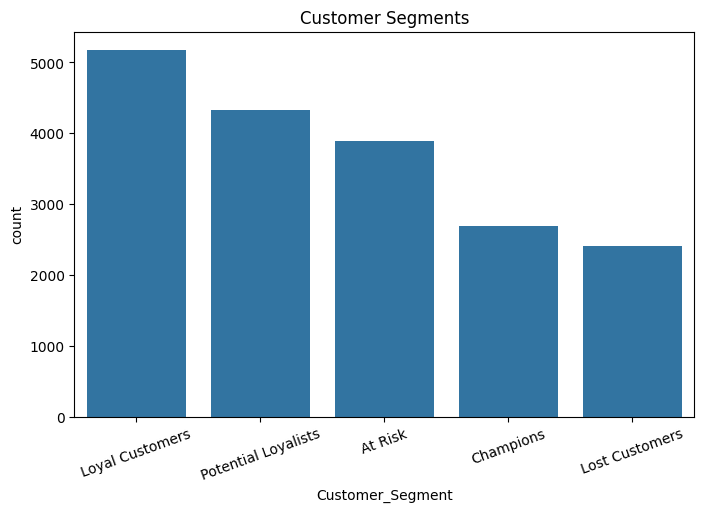

In [61]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=rfm_table,
    x="Customer_Segment",
    order=rfm_table["Customer_Segment"].value_counts().index
)

plt.xticks(rotation=20)
plt.title("Customer Segments")
plt.show()

## Customer Segmentation

Customers were segmented based on their RFM scores to identify purchasing behavior and customer value.

The customer segments are:

- **Champions** – High-value customers with recent and frequent purchases.
- **Loyal Customers** – Customers who purchase regularly and contribute significant revenue.
- **Potential Loyalists** – Customers showing promising purchasing behavior.
- **At Risk** – Customers whose purchasing activity has declined.
- **Lost Customers** – Customers with low recency, frequency, and monetary values.

In [64]:
df = df.merge(
    rfm_table[["CustomerKey","Customer_Segment"]],
    on="CustomerKey",
    how="left"
)

In [65]:
segment_sales = df.groupby("Customer_Segment")["SalesAmount"].sum().sort_values(ascending=False)

segment_sales

Customer_Segment
Loyal Customers        1.227026e+07
Champions              1.198597e+07
Potential Loyalists    3.707360e+06
At Risk                1.241674e+06
Lost Customers         1.534096e+05
Name: SalesAmount, dtype: float64

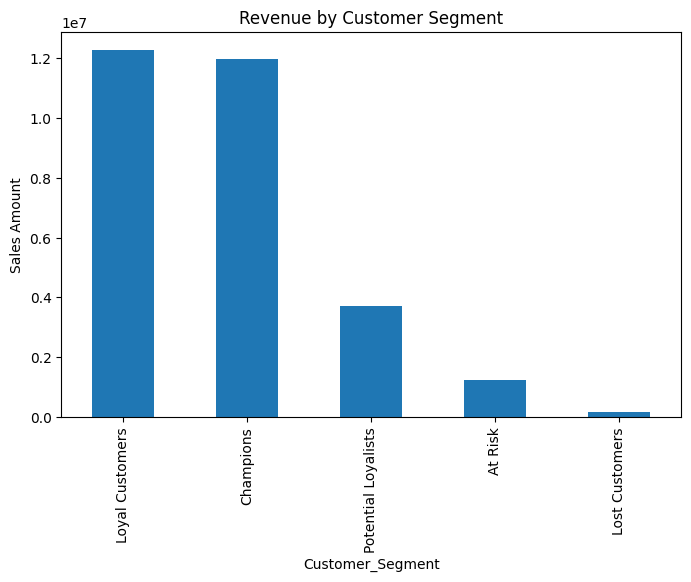

In [66]:
plt.figure(figsize=(8,5))

segment_sales.plot(kind="bar")

plt.title("Revenue by Customer Segment")
plt.ylabel("Sales Amount")
plt.show()

In [67]:
rfm_table.groupby("Customer_Segment")["Monetary"].mean().sort_values(ascending=False)

Customer_Segment
Champions              4460.727068
Loyal Customers        2370.606615
Potential Loyalists     857.589578
At Risk                 319.196513
Lost Customers           63.708293
Name: Monetary, dtype: float64

In [68]:
rfm_table.groupby("Customer_Segment")["Frequency"].mean().sort_values(ascending=False)

Customer_Segment
Champions              2.679568
Loyal Customers        1.799266
Potential Loyalists    1.115660
At Risk                1.006427
Lost Customers         1.000000
Name: Frequency, dtype: float64

In [69]:
rfm_table.groupby("Customer_Segment")["Recency"].mean().sort_values()

Customer_Segment
Champions               90.923335
Loyal Customers        169.065301
Potential Loyalists    202.971548
At Risk                214.311311
Lost Customers         285.546096
Name: Recency, dtype: float64

In [70]:
df.groupby("EnglishCountryRegionName")["SalesAmount"].sum().sort_values(ascending=False)

EnglishCountryRegionName
United States     9.389790e+06
Australia         9.061001e+06
United Kingdom    3.391712e+06
Germany           2.894312e+06
France            2.644018e+06
Canada            1.977845e+06
Name: SalesAmount, dtype: float64

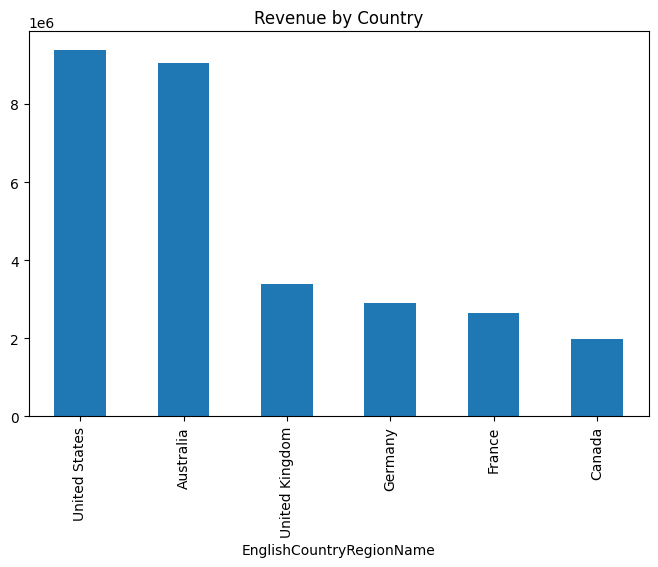

In [71]:
country_sales = df.groupby("EnglishCountryRegionName")["SalesAmount"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

country_sales.plot(kind="bar")

plt.title("Revenue by Country")

plt.show()

In [72]:
top_products = df.groupby("EnglishProductName")["SalesAmount"].sum().sort_values(ascending=False).head(10)

top_products

EnglishProductName
Mountain-200 Black, 46     1.373470e+06
Mountain-200 Black, 42     1.363142e+06
Mountain-200 Silver, 38    1.339463e+06
Mountain-200 Silver, 46    1.301100e+06
Mountain-200 Black, 38     1.294866e+06
Mountain-200 Silver, 42    1.257435e+06
Road-150 Red, 48           1.205877e+06
Road-150 Red, 62           1.202299e+06
Road-150 Red, 52           1.080638e+06
Road-150 Red, 56           1.055590e+06
Name: SalesAmount, dtype: float64

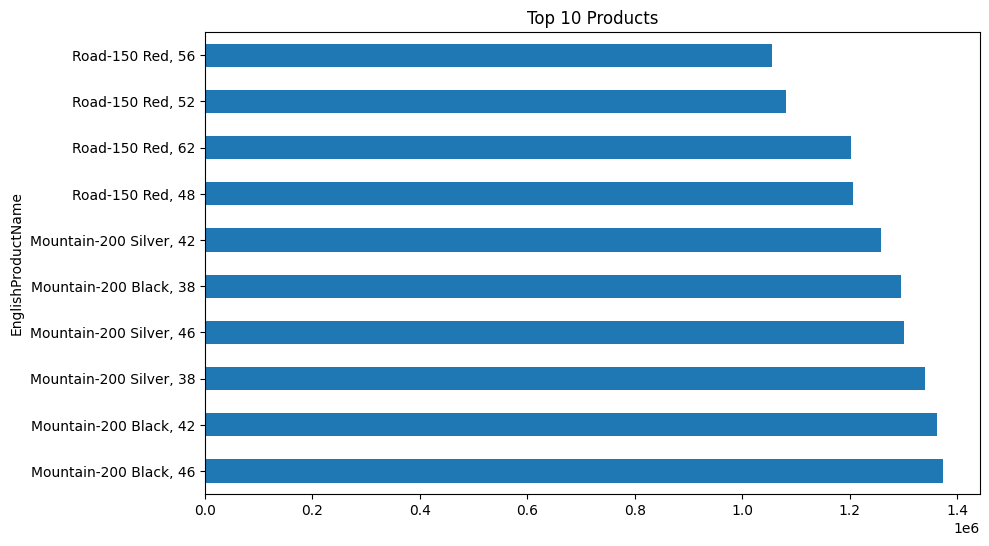

In [73]:
plt.figure(figsize=(10,6))

top_products.plot(kind="barh")

plt.title("Top 10 Products")

plt.show()

In [74]:
pd.crosstab(
    df["Customer_Segment"],
    df["EnglishProductName"]
).head()

EnglishProductName,AWC Logo Cap,All-Purpose Bike Stand,Bike Wash - Dissolver,"Classic Vest, L","Classic Vest, M","Classic Vest, S",Fender Set - Mountain,HL Mountain Tire,HL Road Tire,"Half-Finger Gloves, L","Half-Finger Gloves, M","Half-Finger Gloves, S",Hitch Rack - 4-Bike,Hydration Pack - 70 oz.,LL Mountain Tire,LL Road Tire,"Long-Sleeve Logo Jersey, L","Long-Sleeve Logo Jersey, M","Long-Sleeve Logo Jersey, S","Long-Sleeve Logo Jersey, XL",ML Mountain Tire,ML Road Tire,Mountain Bottle Cage,Mountain Tire Tube,"Mountain-100 Black, 38","Mountain-100 Black, 42","Mountain-100 Black, 44","Mountain-100 Black, 48","Mountain-100 Silver, 38","Mountain-100 Silver, 42","Mountain-100 Silver, 44","Mountain-100 Silver, 48","Mountain-200 Black, 38","Mountain-200 Black, 42","Mountain-200 Black, 46","Mountain-200 Silver, 38","Mountain-200 Silver, 42","Mountain-200 Silver, 46","Mountain-400-W Silver, 38","Mountain-400-W Silver, 40","Mountain-400-W Silver, 42","Mountain-400-W Silver, 46","Mountain-500 Black, 40","Mountain-500 Black, 42","Mountain-500 Black, 44","Mountain-500 Black, 48","Mountain-500 Black, 52","Mountain-500 Silver, 40","Mountain-500 Silver, 42","Mountain-500 Silver, 44","Mountain-500 Silver, 48","Mountain-500 Silver, 52",Patch Kit/8 Patches,"Racing Socks, L","Racing Socks, M",Road Bottle Cage,Road Tire Tube,"Road-150 Red, 44","Road-150 Red, 48","Road-150 Red, 52","Road-150 Red, 56","Road-150 Red, 62","Road-250 Black, 44","Road-250 Black, 48","Road-250 Black, 52","Road-250 Black, 58","Road-250 Red, 44","Road-250 Red, 48","Road-250 Red, 52","Road-250 Red, 58","Road-350-W Yellow, 40","Road-350-W Yellow, 42","Road-350-W Yellow, 44","Road-350-W Yellow, 48","Road-550-W Yellow, 38","Road-550-W Yellow, 40","Road-550-W Yellow, 42","Road-550-W Yellow, 44","Road-550-W Yellow, 48","Road-650 Black, 44","Road-650 Black, 48","Road-650 Black, 52","Road-650 Black, 58","Road-650 Black, 60","Road-650 Black, 62","Road-650 Red, 44","Road-650 Red, 48","Road-650 Red, 52","Road-650 Red, 58","Road-650 Red, 60","Road-650 Red, 62","Road-750 Black, 44","Road-750 Black, 48","Road-750 Black, 52","Road-750 Black, 58","Short-Sleeve Classic Jersey, L","Short-Sleeve Classic Jersey, M","Short-Sleeve Classic Jersey, S","Short-Sleeve Classic Jersey, XL","Sport-100 Helmet, Black","Sport-100 Helmet, Blue","Sport-100 Helmet, Red",Touring Tire,Touring Tire Tube,"Touring-1000 Blue, 46","Touring-1000 Blue, 50","Touring-1000 Blue, 54","Touring-1000 Blue, 60","Touring-1000 Yellow, 46","Touring-1000 Yellow, 50","Touring-1000 Yellow, 54","Touring-1000 Yellow, 60","Touring-2000 Blue, 46","Touring-2000 Blue, 50","Touring-2000 Blue, 54","Touring-2000 Blue, 60","Touring-3000 Blue, 44","Touring-3000 Blue, 50","Touring-3000 Blue, 54","Touring-3000 Blue, 58","Touring-3000 Blue, 62","Touring-3000 Yellow, 44","Touring-3000 Yellow, 50","Touring-3000 Yellow, 54","Touring-3000 Yellow, 58","Touring-3000 Yellow, 62",Water Bottle - 30 oz.,"Women's Mountain Shorts, L","Women's Mountain Shorts, M","Women's Mountain Shorts, S"
Customer_Segment,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
At Risk,378,45,162,30,39,28,320,91,168,64,74,72,44,124,187,317,75,56,71,70,275,155,300,677,1,0,0,0,0,0,0,0,11,9,13,10,7,9,7,5,3,10,14,7,9,6,3,8,7,7,8,8,649,49,56,225,526,0,0,0,0,0,16,14,16,11,0,0,0,11,37,35,24,23,32,20,42,39,31,6,2,7,5,4,1,2,1,2,3,2,3,89,96,84,79,69,54,44,61,378,323,374,162,322,4,2,2,6,2,5,3,5,0,1,0,0,2,2,2,2,3,1,3,4,6,4,831,94,95,80
Champions,480,54,207,37,38,35,405,354,177,101,98,118,71,204,160,116,65,76,74,76,145,142,534,433,35,28,45,40,37,27,28,28,285,315,297,304,286,287,44,34,44,40,4,10,7,17,7,11,8,7,8,8,558,61,70,520,382,101,113,99,93,118,101,106,123,114,71,71,54,125,48,53,50,59,56,52,58,50,49,20,20,37,25,28,23,31,34,21,38,20,30,44,37,53,49,101,100,100,96,458,495,544,226,286,100,75,96,79,94,82,94,81,55,65,49,42,25,22,25,28,33,26,18,22,24,22,930,51,35,31
Lost Customers,186,4,113,12,13,10,319,96,78,36,38

## Business Insights

The RFM segments were analyzed to understand customer purchasing behavior and revenue contribution. The analysis focused on customer distribution, revenue by segment, spending patterns, geographical performance, and top-selling products to support business decision-making.

In [75]:
df.to_csv("Customer_Segmentation.csv", index=False)

In [76]:
df = df.merge(
    rfm_table[
        [
            "CustomerKey",
            "Recency",
            "Frequency",
            "Monetary",
            "RFM_Total"
        ]
    ],
    on="CustomerKey",
    how="left"
)

In [77]:
df.head()

,ProductKey,OrderDateKey,DueDateKey,ShipDateKey,CustomerKey,PromotionKey,CurrencyKey,SalesTerritoryKey,SalesOrderNumber,SalesOrderLineNumber,RevisionNumber,OrderQuantity,UnitPrice,ExtendedAmount,UnitPriceDiscountPct,DiscountAmount,ProductStandardCost,TotalProductCost,SalesAmount,TaxAmt,Freight,OrderDate,DueDate,ShipDate,GeographyKey,FirstName,LastName,Gender,YearlyIncome,EnglishEducation,EnglishOccupation,DateFirstPurchase,City,StateProvinceName,EnglishCountryRegionName,EnglishProductName,Color,ListPrice,EnglishDescription,DateKey,FullDateAlternateKey,EnglishMonthName,CalendarQuarter,CalendarYear,SalesTerritoryAlternateKey,SalesTerritoryRegion,SalesTerritoryCountry,SalesTerritoryGroup,Customer_Segment,Recency,Frequency,Monetary,RFM_Total
0,344,20050722,20050803,20050729,11000,1,6,9,SO43793,1,1,1,3399.99,3399.99,0,0,1912.1544,1912.1544,3399.99,271.9992,84.9998,2005-07-22,2005-08-03,2005-07-29,26,Jon,Yang,Male,90000,Bachelors,Professional,2005-07-22,Rockhampton,Queensland,Australia,"Mountain-100 Silver, 38",Silver,3399.99,Top-of-the-line competition mountain bike. Per...,20050722,2005-07-22,July,3,2005,9,Australia,Australia,Pacific,Loyal Customers,271,3,8248.99,12
1,353,20070722,20070803,20070729,11000,2,6,9,SO51522,1,1,1,2319.99,2319.99,0,0,1265.6195,1265.6195,2319.99,185.5992,57.9998,2007-07-22,2007-08-03,2007-07-29,26,Jon,Yang,Male,90000,Bachelors,Professional,2005-07-22,Rockhampton,Queensland,Australia,"Mountain-200 Silver, 38",Silver,2319.99,Serious back-country riding. Perfect for all l...,20070722,2007-07-22,July,3,2007,9,Australia,Australia,Pacific,Loyal Customers,271,3,8248.99,12
2,485,20070722,20070803,20070729,11000,1,6,9,SO51522,2,1,1,21.98,21.98,0,0,8.2205,8.2205,21.98,1.7584,0.5495,2007-07-22,2007-08-03,2007-07-29,26,Jon,Yang,Male,90000,Bachelors,Professional,2005-07-22,Rockhampton,Queensland,Australia,Fender Set - Mountain,No Color,21.98,Clip-on fenders fit most mountain bikes.,20070722,2007-07-22,July,3,2007,9,Australia,Australia,Pacific,Loyal Customers,271,3,8248.99,12
3,573,20071104,20071116,20071111,11000,1,6,9,SO57418,1,1,1,2384.07,2384.07,0,0,1481.9379,1481.9379,2384.07,190.7256,59.6018,2007-11-04,2007-11-16,2007-11-11,26,Jon,Yang,Male,90000,Bachelors,Professional,2005-07-22,Rockhampton,Queensland,Australia,"Touring-1000 Blue, 46",Blue,2384.07,Travel in style and comfort. Designed for maxi...,20071104,2007-11-04,November,4,2007,9,Australia,Australia,Pacific,Loyal Customers,271,3,8248.99,12
4,541,20071104,20071116,20071111,11000,1,6,9,SO57418,2,1,1,28.99,28.99,0,0,10.8423,10.8423,28.99,2.3192,0.7248,2007-11-04,2007-11-16,2007-11-11,26,Jon,Yang,Male,90000,Bachelors,Professional,2005-07-22,Rockhampton,Queensland,Australia,Touring Tire,No Color,28.99,High-density rubber.,20071104,2007-11-04,November,4,2007,9,Australia,Australia,Pacific,Loyal Customers,271,3,8248.99,12


In [78]:
df.drop(
    columns=[
        "DueDateKey",
        "ShipDateKey",
        "PromotionKey",
        "CurrencyKey",
        "SalesOrderLineNumber",
        "RevisionNumber",
        "UnitPriceDiscountPct",
        "DiscountAmount",
        "ProductStandardCost",
        "ExtendedAmount",
        "TotalProductCost",
        "DueDate",
        "ShipDate",
        "SalesTerritoryAlternateKey"
    ],
    inplace=True
)

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60398 entries, 0 to 60397
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   ProductKey                60398 non-null  int64         
 1   OrderDateKey              60398 non-null  int64         
 2   CustomerKey               60398 non-null  int64         
 3   SalesTerritoryKey         60398 non-null  int64         
 4   SalesOrderNumber          60398 non-null  object        
 5   OrderQuantity             60398 non-null  int64         
 6   UnitPrice                 60398 non-null  float64       
 7   SalesAmount               60398 non-null  float64       
 8   TaxAmt                    60398 non-null  float64       
 9   Freight                   60398 non-null  float64       
 10  OrderDate                 60398 non-null  datetime64[ns]
 11  GeographyKey              60398 non-null  int64         
 12  FirstName         

In [80]:
df.drop(
    columns=[
        "OrderDateKey",
        "DateKey",
        "FullDateAlternateKey"
    ],
    inplace=True
)

In [81]:
df.to_csv("Customer_Segmentation.csv", index=False)